# Notebook 06 - Error Analysis, Failure Modes, and Lessons Learned

This notebook turns metric deltas into actionable model-improvement hypotheses.

## What Is This Technique? - Structured Legal Error Analysis

### Definition and Core Concepts
Error analysis inspects concrete examples to explain misses, hallucinations, and misclassifications.

### Why Was This Technique Developed?
Aggregate metrics do not reveal root causes.

### What Limitations of Traditional RAG Does It Solve?
RAG may reduce unsupported claims by grounding, but legal extraction errors still occur if the generator is not specialized.

### Architecture and Workflow Diagram Explanation
```mermaid
flowchart LR
A[Predictions + references] --> B[Error slicing]
B --> C[Missed risks]
B --> D[Hallucinated obligations]
B --> E[Liability extraction failures]
C --> F[Actionable remediations]
D --> F
E --> F
```

### Component-by-Component Breakdown
1. Hallucination rate report.
2. Confusion matrix inspection.
3. Row-level prediction/reference comparison.
4. Error taxonomy and remediation ideas.

### When Should It Be Used in Real-World Systems?
Use after every major model iteration before production promotion.

### Advantages and Disadvantages
Advantages:
- Surfaces concrete failure patterns.
- Improves data and prompt decisions.
- Supports risk-focused legal QA.

Disadvantages:
- Requires manual review effort.
- Can be biased by small slices if sample size is low.

### Comparison Against Standard RAG and Other Implemented Variants
Compared with standard RAG debugging, this notebook focuses on output schema and legal decision quality rather than retrieval-only tuning.

### Implementation Details and Design Decisions Used in This Project
Error artifacts and visualizations are generated in the evaluation stage and inspected here.


In [1]:
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
ROOT = next((p for p in candidates if (p / 'scripts').exists() and (p / 'configs').exists()), cwd)
print('Project root:', ROOT)

def run_py(script: str, *args: str) -> None:
    cmd = [sys.executable, str(ROOT / script), *args]
    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, check=True, cwd=str(ROOT))


Project root: /home/ahmad/AI/Legal-Document-Summarizer-Clause-Analyzer


In [2]:
run_dir = ROOT / 'artifacts/runs/balanced_local_v1'
pred_file = run_dir / 'predictions_fine_tuned_adapter.jsonl'
if not pred_file.exists():
    pred_file = run_dir / 'predictions_qwen_zero_shot.jsonl'

rows = []
with pred_file.open() as f:
    for line in f:
        rows.append(json.loads(line))
len(rows), pred_file.name

(36, 'predictions_fine_tuned_adapter.jsonl')

In [3]:
hall = json.loads((ROOT / 'artifacts/metrics/hallucination_report.json').read_text())
pd.DataFrame(hall).T

,unsupported_claim_rate,missing_obligation_rate,missing_liability_rate
few_shot,0.0,1.0,1.0
fine_tuned_adapter,0.0,1.0,1.0
granite_zero_shot,0.0,1.0,1.0
prompt_only,0.0,1.0,1.0
qwen_zero_shot,0.0,1.0,1.0


In [4]:
records = []
for row in rows[:25]:
    records.append({
        'row_id': row['row_id'],
        'dataset': row['dataset'],
        'ref_risk': row['reference']['risk_level'],
        'pred_risk': row['prediction']['risk_level'],
        'ref_liabilities': ', '.join(row['reference'].get('liabilities', [])),
        'pred_liabilities': ', '.join(row['prediction'].get('liabilities', [])),
    })
pd.DataFrame(records).head(10)

,row_id,dataset,ref_risk,pred_risk,ref_liabilities,pred_liabilities
0,ledgar_test_000000,ledgar,low,medium,contractual liability,
1,ledgar_test_000001,ledgar,low,medium,contractual liability,
2,ledgar_test_000002,ledgar,low,medium,contractual liability,
3,ledgar_test_000003,ledgar,medium,medium,financial liability,
4,ledgar_test_000004,ledgar,low,medium,contractual liability,
5,ledgar_test_000005,ledgar,low,medium,contractual liability,
6,ledgar_test_000006,ledgar,medium,medium,contractual liability,
7,ledgar_test_000007,ledgar,low,medium,contractual liability,
8,ledgar_test_000008,ledgar,high,medium,"financial liability, contractual liability",
9,ledgar_test_000009,ledgar,high,medium,financial liability,


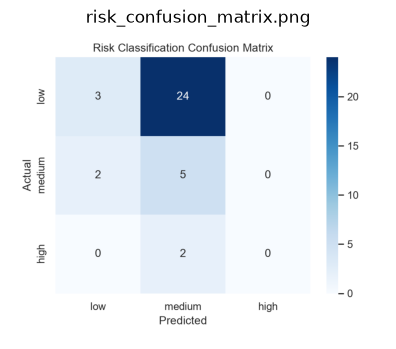

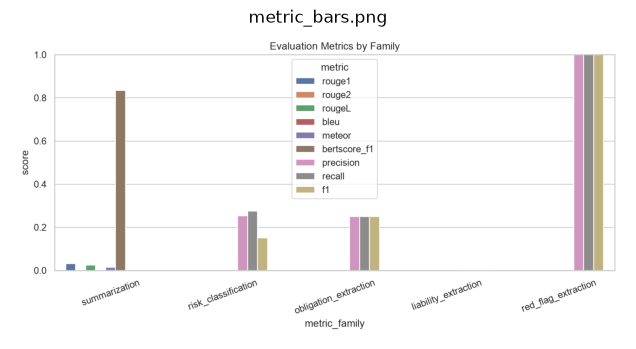

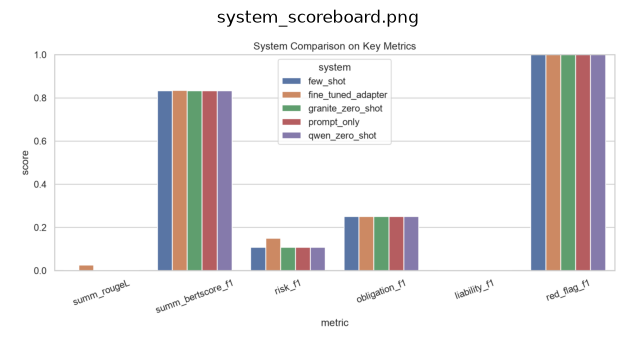

In [5]:
for name in ['risk_confusion_matrix.png', 'metric_bars.png', 'system_scoreboard.png']:
    p = ROOT / 'artifacts/figures' / name
    if p.exists():
        plt.figure(figsize=(10, 4))
        plt.imshow(plt.imread(p))
        plt.axis('off')
        plt.title(name)
        plt.show()

## Lessons Learned and Practical Takeaways

1. Review row-level errors, not only aggregate metrics.
2. Fix recurring misses with targeted data improvements or adapter retraining.
3. Keep hallucination checks as a mandatory legal safety gate.